In [8]:
library(tidyverse) 


Warning message:
"package 'tidyverse' was built under R version 4.3.3"
Warning message:
"package 'tibble' was built under R version 4.3.3"
Warning message:
"package 'tidyr' was built under R version 4.3.3"
Warning message:
"package 'readr' was built under R version 4.3.3"
Warning message:
"package 'purrr' was built under R version 4.3.3"
Warning message:
"package 'stringr' was built under R version 4.3.3"
Warning message:
"package 'forcats' was built under R version 4.3.3"
Warning message:
"package 'lubridate' was built under R version 4.3.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ psych::%+%()    masks ggplot2::%+%()
✖ psych::alpha()  masks ggplot2::alpha()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks st

In [10]:
train <- read_csv("C:/Users/yen/Downloads/train.csv", show_col_types = FALSE)
test <- read_csv("C:/Users/yen/Downloads/test.csv", show_col_types = FALSE)

In [11]:
head(train)

date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Day,Week_Status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
4/7/2018 17:15,4.18,0.00,21.78,0.00,100.00,18.85,62100,1,Sat,0
5/30/2018 2:45,2.92,4.93,0.00,0.00,50.96,100.00,9900,0,Wed,1
2/23/2018 1:45,6.44,7.34,0.00,0.00,65.95,100.00,6300,0,Fri,1
12/13/2018 13:30,56.92,22.28,0.00,0.03,93.12,100.00,48600,1,Thu,1
4/15/2018 2:45,3.10,3.82,0.00,0.00,63.01,100.00,9900,0,Sun,0
7/23/2018 16:30,55.51,30.06,0.00,0.03,87.93,100.00,59400,2,Mon,1


In [12]:
head(test)

date,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Day,Week_Status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
4/29/2018 7:15,3.82,0.0,0.00,60.20,100.00,26100,0,Sun,0
10/4/2018 12:00,48.02,0.0,0.03,78.46,100.00,43200,2,Thu,1
1/26/2018 11:30,59.65,0.0,0.06,89.61,100.00,41400,2,Fri,1
6/2/2018 14:30,0.00,16.6,0.00,100.00,18.53,52200,0,Sat,0
12/7/2018 15:00,20.99,0.0,0.03,94.19,100.00,54000,1,Fri,1
3/26/2018 6:00,3.49,0.0,0.00,66.41,100.00,21600,0,Mon,1


In [13]:
summary(train)

     date             Usage_kWh      Lagging_Current_Reactive.Power_kVarh
 Length:28032       Min.   :  0.00   Min.   : 0.00                       
 Class :character   1st Qu.:  3.20   1st Qu.: 2.27                       
 Mode  :character   Median :  4.57   Median : 5.00                       
                    Mean   : 27.29   Mean   :12.99                       
                    3rd Qu.: 51.05   3rd Qu.:22.57                       
                    Max.   :157.18   Max.   :96.91                       
 Leading_Current_Reactive_Power_kVarh   CO2(tCO2)      
 Min.   : 0.000                       Min.   :0.00000  
 1st Qu.: 0.000                       1st Qu.:0.00000  
 Median : 0.000                       Median :0.00000  
 Mean   : 3.888                       Mean   :0.01146  
 3rd Qu.: 2.120                       3rd Qu.:0.02000  
 Max.   :27.760                       Max.   :0.07000  
 Lagging_Current_Power_Factor Leading_Current_Power_Factor      NSM       
 Min.   :  0.00

In [14]:
miss <- sapply(train, function(x)sum(is.na(x)))
miss

date                            Usage_kWh 
                                   0                                    0 
Lagging_Current_Reactive.Power_kVarh Leading_Current_Reactive_Power_kVarh 
                                   0                                    0 
                           CO2(tCO2)         Lagging_Current_Power_Factor 
                                   0                                    0 
        Leading_Current_Power_Factor                                  NSM 
                                   0                                    0 
                           Load_Type                                  Day 
                                   0                                    0 
                         Week_Status 
                                   0

In [15]:
miss1 <- sapply(test, function(x)sum(is.na(x)))
miss1

date Lagging_Current_Reactive.Power_kVarh 
                                   0                                    0 
Leading_Current_Reactive_Power_kVarh                            CO2(tCO2) 
                                   0                                    0 
        Lagging_Current_Power_Factor         Leading_Current_Power_Factor 
                                   0                                    0 
                                 NSM                            Load_Type 
                                   0                                    0 
                                 Day                          Week_Status 
                                   0                                    0

In [16]:
numeric_data <- train %>% select_if(is.numeric)
head(numeric_data)

Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Week_Status
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4.18,0.00,21.78,0.00,100.00,18.85,62100,1,0
2.92,4.93,0.00,0.00,50.96,100.00,9900,0,1
6.44,7.34,0.00,0.00,65.95,100.00,6300,0,1
56.92,22.28,0.00,0.03,93.12,100.00,48600,1,1
3.10,3.82,0.00,0.00,63.01,100.00,9900,0,0
55.51,30.06,0.00,0.03,87.93,100.00,59400,2,1


In [17]:
test$date = as.POSIXct(test$date)
train$date = as.POSIXct(train$date)

ERROR: Error in as.POSIXlt.character(x, tz, ...): character string is not in a standard unambiguous format


In [18]:
# Encode logical columns as binary (0 and 1)
logical_cols <- sapply(train, is.logical)
train[logical_cols] <- lapply(train[logical_cols], as.numeric)

# Display the transformed data
head(train)

date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Day,Week_Status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
4/7/2018 17:15,4.18,0.00,21.78,0.00,100.00,18.85,62100,1,Sat,0
5/30/2018 2:45,2.92,4.93,0.00,0.00,50.96,100.00,9900,0,Wed,1
2/23/2018 1:45,6.44,7.34,0.00,0.00,65.95,100.00,6300,0,Fri,1
12/13/2018 13:30,56.92,22.28,0.00,0.03,93.12,100.00,48600,1,Thu,1
4/15/2018 2:45,3.10,3.82,0.00,0.00,63.01,100.00,9900,0,Sun,0
7/23/2018 16:30,55.51,30.06,0.00,0.03,87.93,100.00,59400,2,Mon,1


In [19]:
# Encode logical columns as binary (0 and 1)
logical_cols <- sapply(test, is.logical)
test[logical_cols] <- lapply(test[logical_cols], as.numeric)

# Display the transformed data
head(test)

date,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Day,Week_Status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
4/29/2018 7:15,3.82,0.0,0.00,60.20,100.00,26100,0,Sun,0
10/4/2018 12:00,48.02,0.0,0.03,78.46,100.00,43200,2,Thu,1
1/26/2018 11:30,59.65,0.0,0.06,89.61,100.00,41400,2,Fri,1
6/2/2018 14:30,0.00,16.6,0.00,100.00,18.53,52200,0,Sat,0
12/7/2018 15:00,20.99,0.0,0.03,94.19,100.00,54000,1,Fri,1
3/26/2018 6:00,3.49,0.0,0.00,66.41,100.00,21600,0,Mon,1


In [20]:
# Load libraries
library(dplyr)
library(ggplot2)
library(psych)

In [21]:
describe(numeric_data)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Usage_kWh,1,28032,2.728607e+01,3.337554e+01,4.57,2.117680e+01,2.609376,0,157.18,157.18,1.204191250,0.4111308,1.993431e-01
Lagging_Current_Reactive.Power_kVarh,2,28032,1.299252e+01,1.627127e+01,5.00,1.000413e+01,7.413000,0,96.91,96.91,1.440877787,1.2235857,9.718391e-02
Leading_Current_Reactive_Power_kVarh,3,28032,3.887758e+00,7.441414e+00,0.00,2.145029e+00,0.000000,0,27.76,27.76,1.726364178,1.5477113,4.444556e-02
CO2(tCO2),4,28032,1.146154e-02,1.610322e-02,0.00,8.530277e-03,0.000000,0,0.07,0.07,1.156137815,0.2320717,9.618019e-05
Lagging_Current_Power_Factor,5,28032,8.055450e+01,1.893443e+01,87.95,8.236053e+01,17.865330,0,100.00,100.00,-0.602314930,-1.1023396,1.130903e-01
Leading_Current_Power_Factor,6,28032,8.433698e+01,3.049233e+01,100.00,9.061371e+01,0.000000,0,100.00,100.00,-1.509560261,0.3749460,1.821225e-01
NSM,7,28032,4.263869e+04,2.491345e+04,42300.00,4.262206e+04,32024.160000,0,85500.00,85500.00,0.004317129,-1.1980775,1.488013e+02
Load_Type,8,28032,6.886772e-01,7.913973e-01,0.00,6.108535e-01,0.000000,0,2.00,2.00,0.612887608,-1.1443383,4.726803e-03
Week_Status,9,28032,7.145405e-01,4.516411e-01,1.00,7.681709e-01,0.000000,0,1.00,1.00,-0.950014932,-1.0975108,2.697531e-03


Some variables have a clearly right-skewed distribution (Usage_kWh, Lagging_Current_Reactive_Power_kVarh, Leading_Current_Reactive_Power_kVarh, CO2).

Some variables have a left-skewed distribution (Lagging_Current_Power_Factor, Leading_Current_Power_Factor).

The NSM variable has a near normal distribution. The min and max values ​​of some variables indicate the presence of outliers.

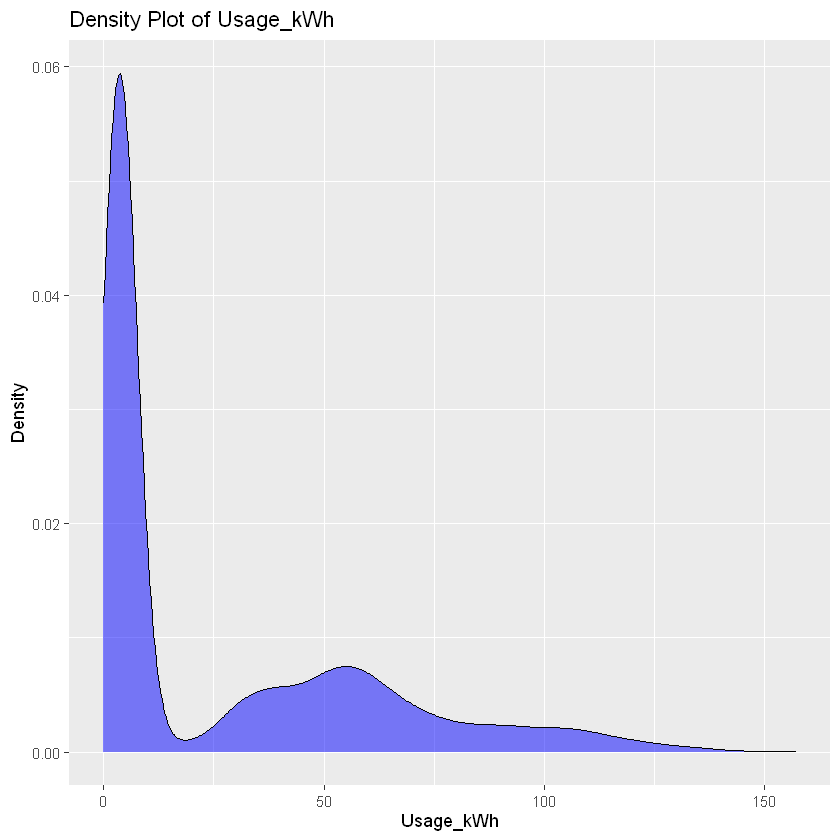

In [22]:
# Vẽ biểu đồ mật độ cho từng biến
# Usage_kWh
ggplot(train, aes(x=Usage_kWh)) + 
  geom_density(fill="blue", alpha=0.5) + 
  ggtitle("Density Plot of Usage_kWh") + 
  xlab("Usage_kWh") + 
  ylab("Density")

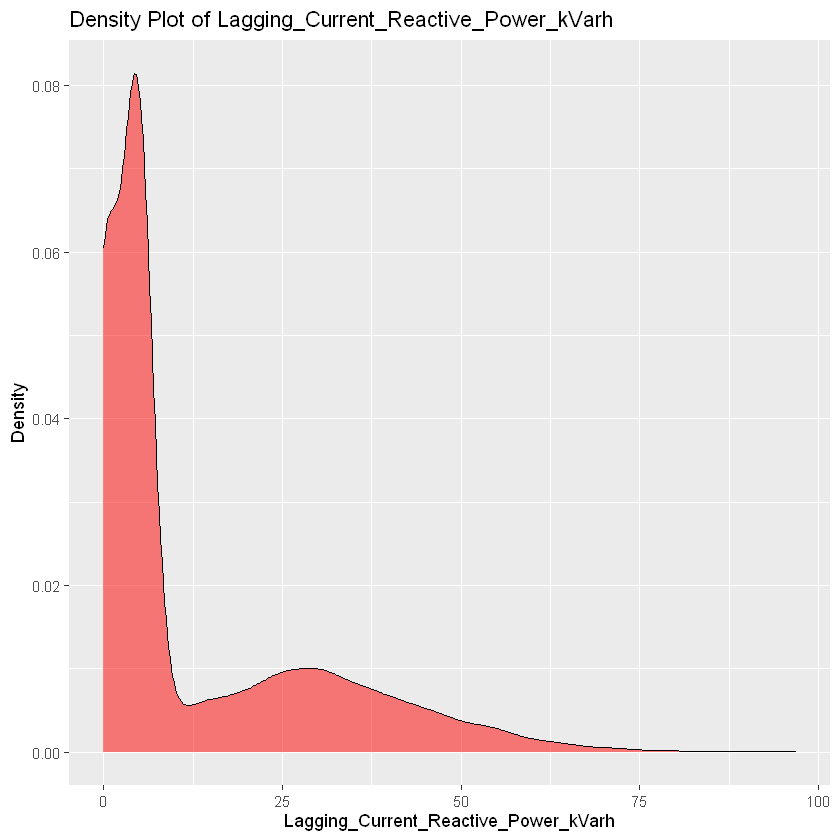

In [28]:
# Lagging_Current_Reactive_Power_kVarh
ggplot(train, aes(x=Lagging_Current_Reactive.Power_kVarh)) + 
  geom_density(fill="red", alpha=0.5) + 
  ggtitle("Density Plot of Lagging_Current_Reactive_Power_kVarh") + 
  xlab("Lagging_Current_Reactive_Power_kVarh") + 
  ylab("Density")

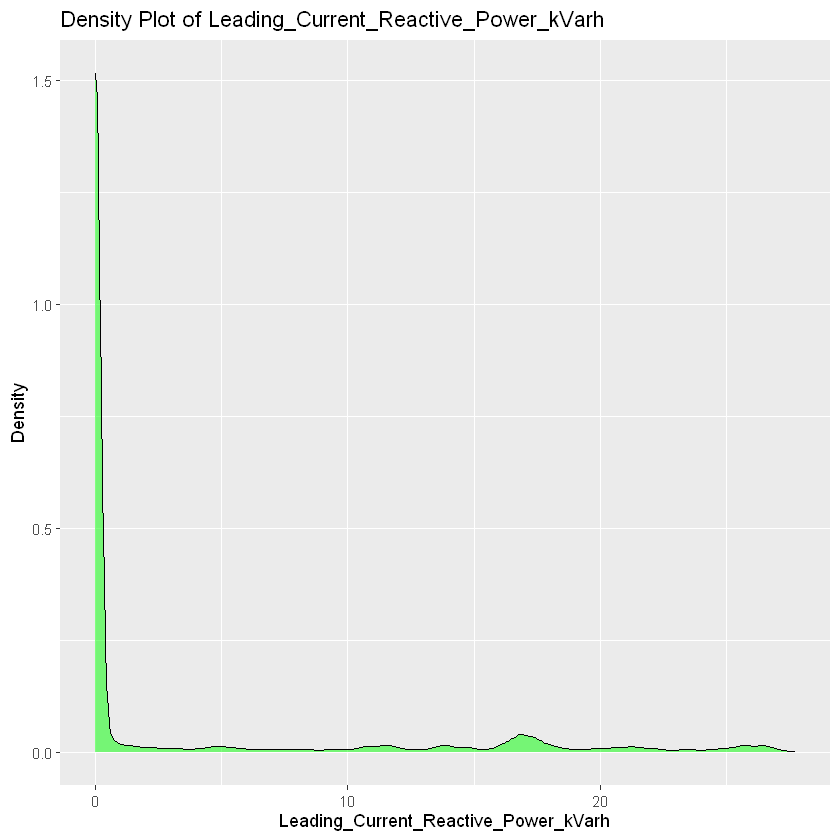

In [29]:
# Leading_Current_Reactive_Power_kVarh
ggplot(train, aes(x=Leading_Current_Reactive_Power_kVarh)) + 
  geom_density(fill="green", alpha=0.5) + 
  ggtitle("Density Plot of Leading_Current_Reactive_Power_kVarh") + 
  xlab("Leading_Current_Reactive_Power_kVarh") + 
  ylab("Density")

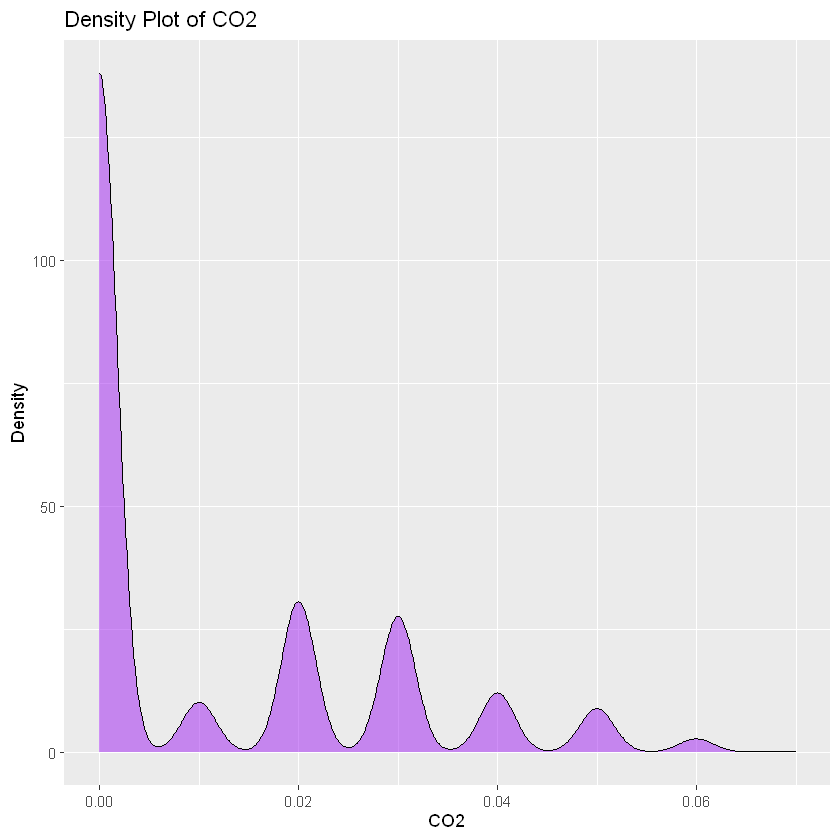

In [30]:
ggplot(train, aes(x= `CO2(tCO2)`)) + 
  geom_density(fill="purple", alpha=0.5) + 
  ggtitle("Density Plot of CO2") + 
  xlab("CO2") + 
  ylab("Density")

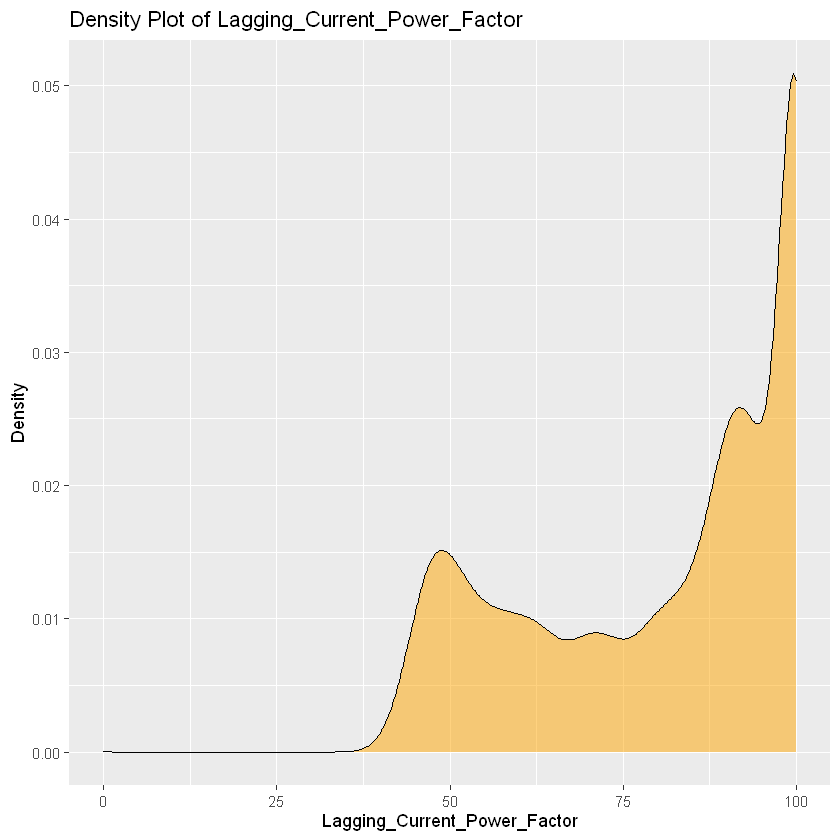

In [31]:
ggplot(train, aes(x=Lagging_Current_Power_Factor)) + 
  geom_density(fill="orange", alpha=0.5) + 
  ggtitle("Density Plot of Lagging_Current_Power_Factor") + 
  xlab("Lagging_Current_Power_Factor") + 
  ylab("Density")

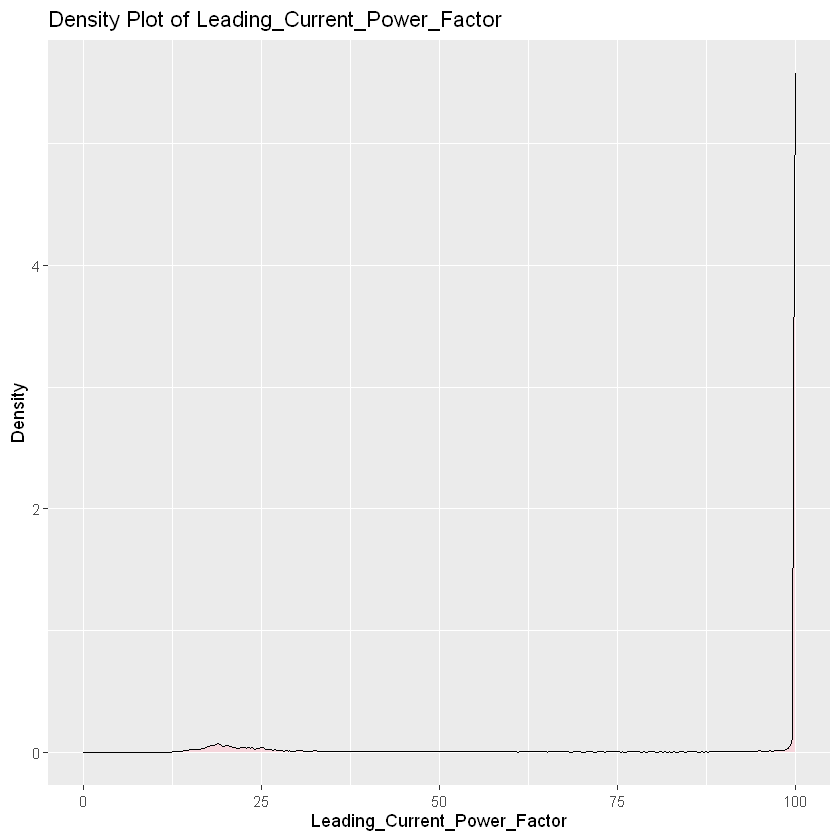

In [32]:
ggplot(train, aes(x=Leading_Current_Power_Factor)) + 
  geom_density(fill="pink", alpha=0.5) + 
  ggtitle("Density Plot of Leading_Current_Power_Factor") + 
  xlab("Leading_Current_Power_Factor") + 
  ylab("Density")

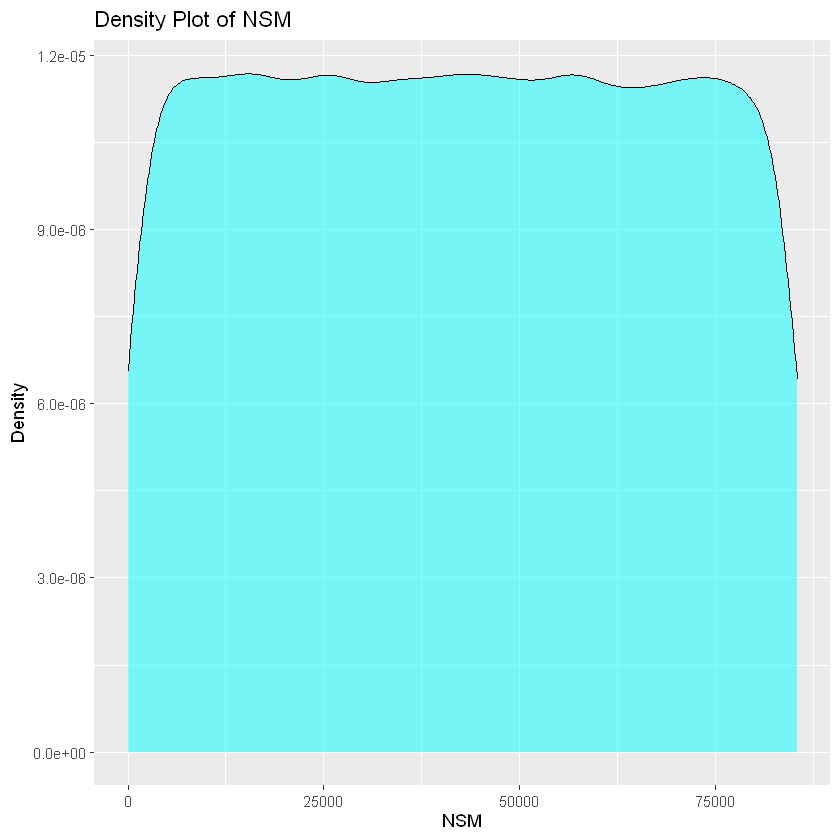

In [33]:
ggplot(train, aes(x=NSM)) + 
  geom_density(fill="cyan", alpha=0.5) + 
  ggtitle("Density Plot of NSM") + 
  xlab("NSM") + 
  ylab("Density")

In [23]:
# Tính IQR cho từng cột số
Q1 <- apply(numeric_data, 2, quantile, probs = 0.25)
Q3 <- apply(numeric_data, 2, quantile, probs = 0.75)
IQR <- Q3 - Q1

In [24]:
print("Thông tin về Q1, Q3 và IQR:")
print(data.frame(Q1, Q3, IQR))

[1] "Thông tin về Q1, Q3 và IQR:"
                                             Q1       Q3        IQR
Usage_kWh                                3.2000    51.05    47.8500
Lagging_Current_Reactive.Power_kVarh     2.2700    22.57    20.3000
Leading_Current_Reactive_Power_kVarh     0.0000     2.12     2.1200
CO2(tCO2)                                0.0000     0.02     0.0200
Lagging_Current_Power_Factor            63.2075    99.06    35.8525
Leading_Current_Power_Factor            99.6900   100.00     0.3100
NSM                                  20700.0000 63900.00 43200.0000
Load_Type                                0.0000     1.00     1.0000
Week_Status                              0.0000     1.00     1.0000


In [25]:
num_rows_before <- nrow(train)
print(paste("Số lượng hàng trước khi áp dụng loại bỏ ngoại lệ:", num_rows_before))

[1] "Số lượng hàng trước khi áp dụng loại bỏ ngoại lệ: 28032"


In [26]:
# Create a copy of the original dataset to apply outlier removal
data <- train
# Áp dụng loại bỏ ngoại lệ
for (col in colnames(numeric_data)) {
  data <- data %>%
    filter((!!sym(col) >= (Q1[col] - 1.5 * IQR[col])) & 
           (!!sym(col) <= (Q3[col] + 1.5 * IQR[col])))
}

In [27]:
# In ra số lượng hàng sau khi áp dụng loại bỏ ngoại lệ
num_rows_after <- nrow(data)
print(paste("Số lượng hàng sau khi áp dụng loại bỏ ngoại lệ:", num_rows_after))

[1] "Số lượng hàng sau khi áp dụng loại bỏ ngoại lệ: 20384"


In [28]:
head(data)

date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Day,Week_Status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
5/30/2018 2:45,2.92,4.93,0.00,0.00,50.96,100,9900,0,Wed,1
2/23/2018 1:45,6.44,7.34,0.00,0.00,65.95,100,6300,0,Fri,1
12/13/2018 13:30,56.92,22.28,0.00,0.03,93.12,100,48600,1,Thu,1
4/15/2018 2:45,3.10,3.82,0.00,0.00,63.01,100,9900,0,Sun,0
7/23/2018 16:30,55.51,30.06,0.00,0.03,87.93,100,59400,2,Mon,1
3/27/2018 16:30,37.26,3.85,0.32,0.02,99.47,100,59400,2,Tue,1


In [29]:
library(reshape2)

In [30]:
numeric <- data %>% select_if(is.numeric)

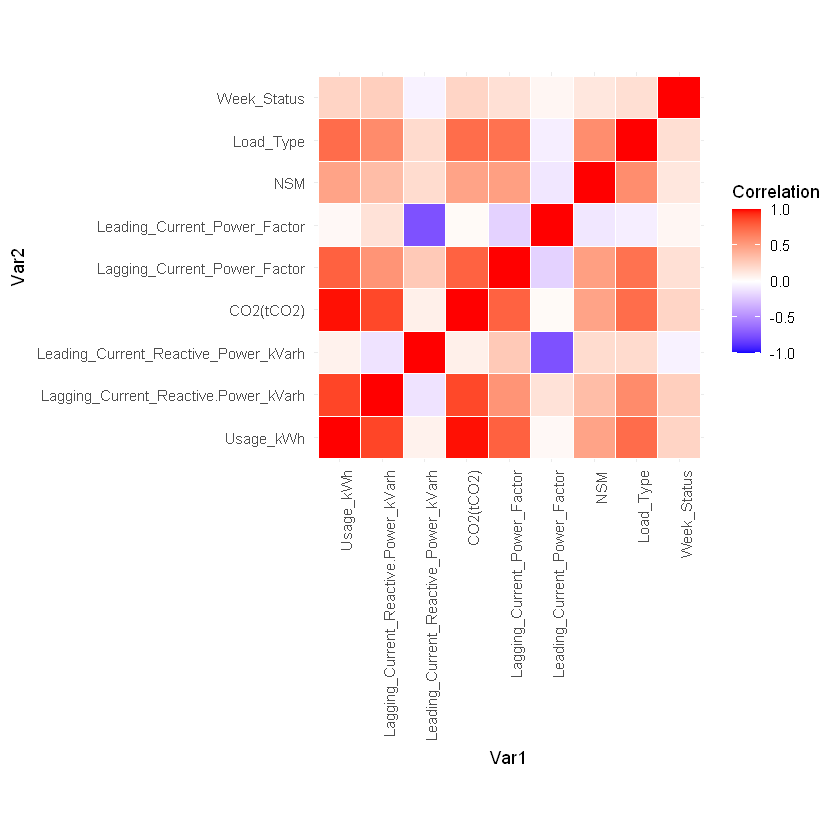

In [31]:
corr_matrix <- cor(numeric, use = "complete.obs")
corr_df <- melt(corr_matrix)

ggplot(data = corr_df, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", 
                       midpoint = 0, limit = c(-1, 1), space = "Lab", 
                       name="Correlation") +
  theme_minimal() + 
  theme(axis.text.x = element_text(angle = 90, vjust = 1, 
                                   size = 9, hjust = 1)) +
  coord_fixed()


In [32]:
cat("Nhận xét và đánh giá:\n")
for (i in 1:(ncol(corr_matrix) - 1)) {
  for (j in (i + 1):ncol(corr_matrix)) {
    corr_value <- corr_matrix[i, j]
    if (!is.na(corr_value)) {
      cat(paste("Mối quan hệ giữa", colnames(corr_matrix)[i], "và", colnames(corr_matrix)[j], "là:", corr_value, "\n"))
      if (abs(corr_value) > 0.7) {
        cat(" -> Tương quan mạnh\n")
      } else if (abs(corr_value) > 0.3) {
        cat(" -> Tương quan trung bình\n")
      } else {
        cat(" -> Tương quan yếu\n")
      }
    }
  }
}

Nhận xét và đánh giá:
Mối quan hệ giữa Usage_kWh và Lagging_Current_Reactive.Power_kVarh là: 0.877523518026406 
 -> Tương quan mạnh
Mối quan hệ giữa Usage_kWh và Leading_Current_Reactive_Power_kVarh là: 0.0706463842431137 
 -> Tương quan yếu
Mối quan hệ giữa Usage_kWh và CO2(tCO2) là: 0.98817916891447 
 -> Tương quan mạnh
Mối quan hệ giữa Usage_kWh và Lagging_Current_Power_Factor là: 0.77552267531364 
 -> Tương quan mạnh
Mối quan hệ giữa Usage_kWh và Leading_Current_Power_Factor là: 0.0348025672530405 
 -> Tương quan yếu
Mối quan hệ giữa Usage_kWh và NSM là: 0.474931727909931 
 -> Tương quan trung bình
Mối quan hệ giữa Usage_kWh và Load_Type là: 0.730604297693321 
 -> Tương quan mạnh
Mối quan hệ giữa Usage_kWh và Week_Status là: 0.226670125547729 
 -> Tương quan yếu
Mối quan hệ giữa Lagging_Current_Reactive.Power_kVarh và Leading_Current_Reactive_Power_kVarh là: -0.120370783378772 
 -> Tương quan yếu
Mối quan hệ giữa Lagging_Current_Reactive.Power_kVarh và CO2(tCO2) là: 0.8691774684801

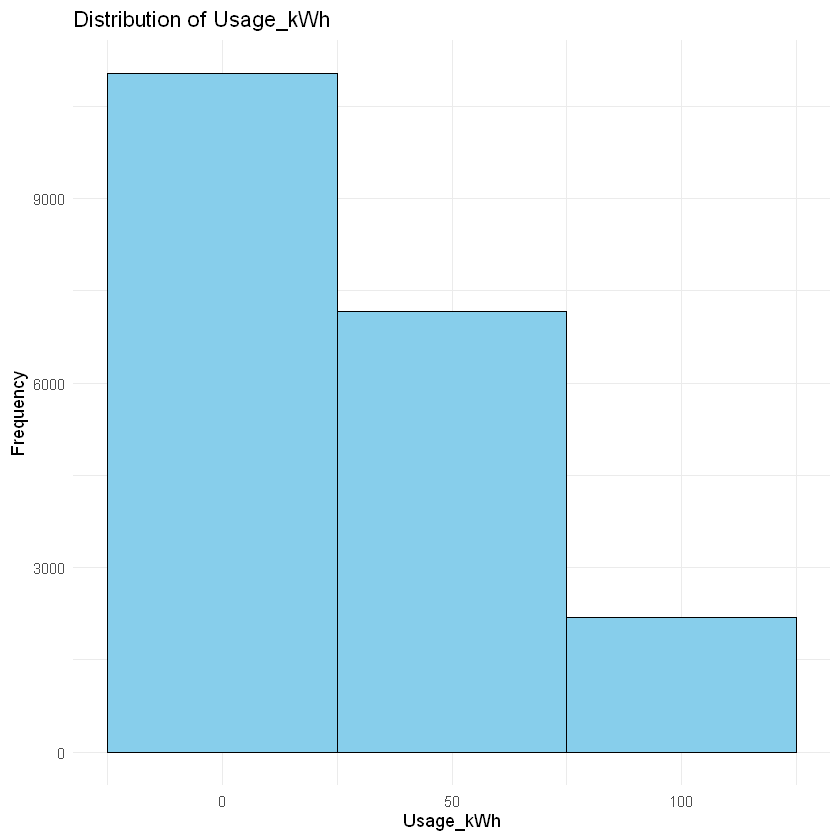

In [33]:
# Vẽ biểu đồ phân phối cho biến Usage_kWh

ggplot(data, aes(x = Usage_kWh)) +
  geom_histogram(binwidth = 50, fill = "skyblue", color = "black") +
  labs(title = "Distribution of Usage_kWh", x = "Usage_kWh", y = "Frequency") +
  theme_minimal()

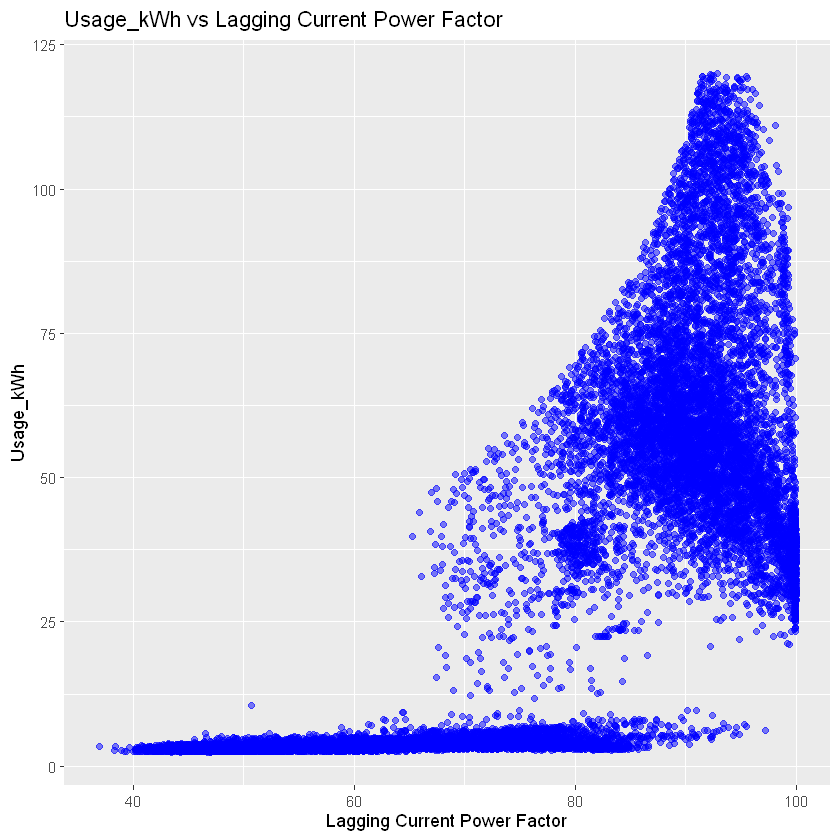

In [34]:
ggplot(data, aes(x=Lagging_Current_Power_Factor, y=Usage_kWh)) + geom_point(color="blue", alpha=0.5) + labs(title="Usage_kWh vs Lagging Current Power Factor", x="Lagging Current Power Factor", y="Usage_kWh")

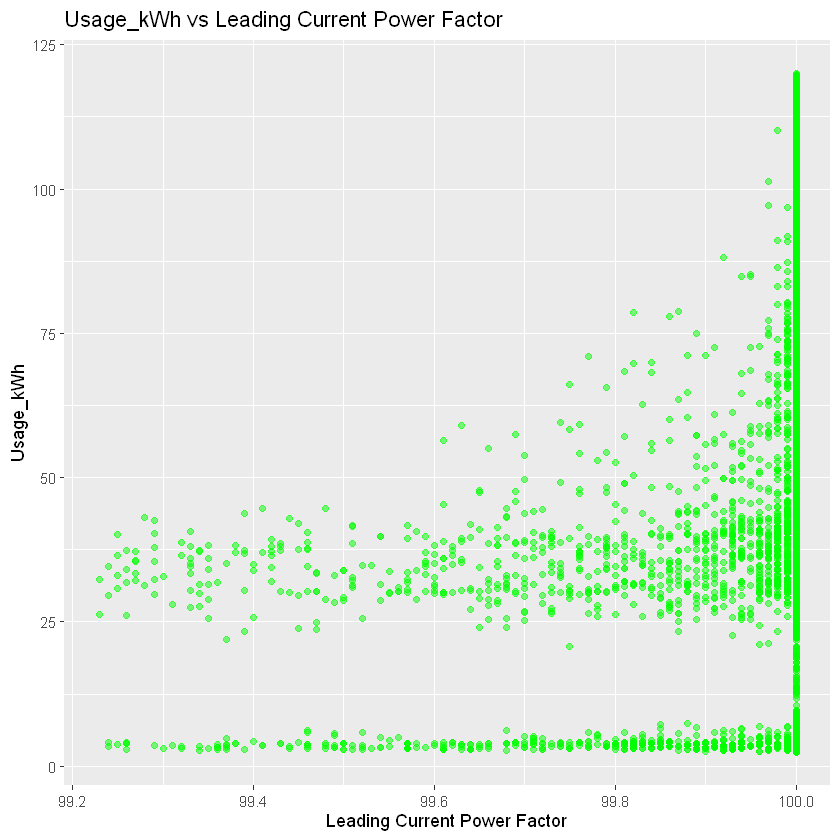

In [35]:
ggplot(data, aes(x=Leading_Current_Power_Factor, y=Usage_kWh)) + geom_point(color="green", alpha=0.5) + labs(title="Usage_kWh vs Leading Current Power Factor", x="Leading Current Power Factor", y="Usage_kWh")

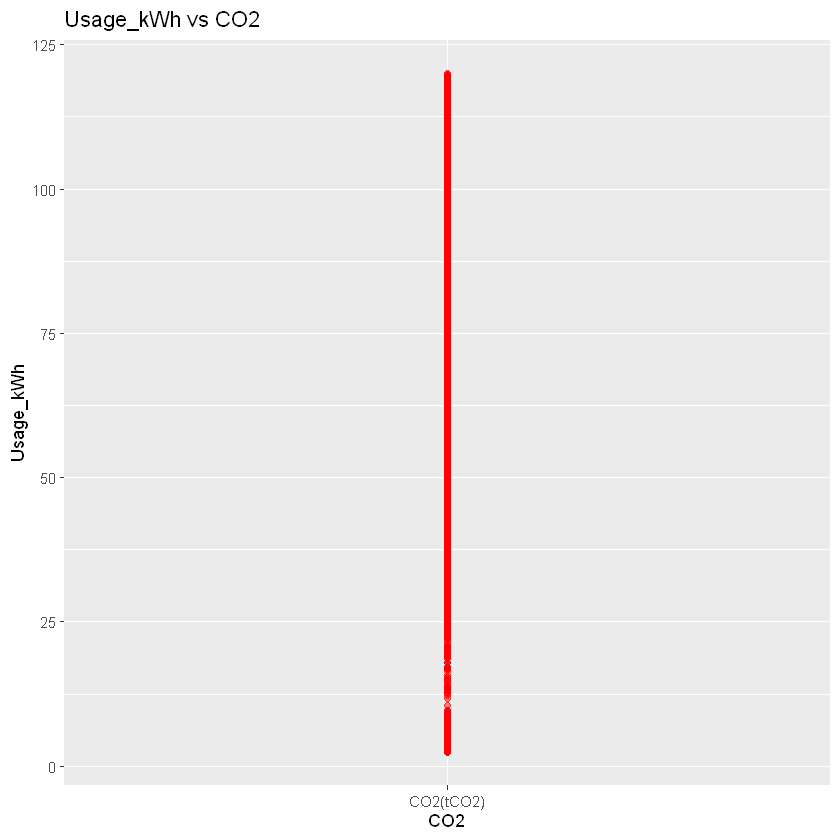

In [36]:
ggplot(data, aes(x="CO2(tCO2)", y=Usage_kWh)) + geom_point(color="red", alpha=0.5) + labs(title="Usage_kWh vs CO2", x="CO2", y="Usage_kWh")

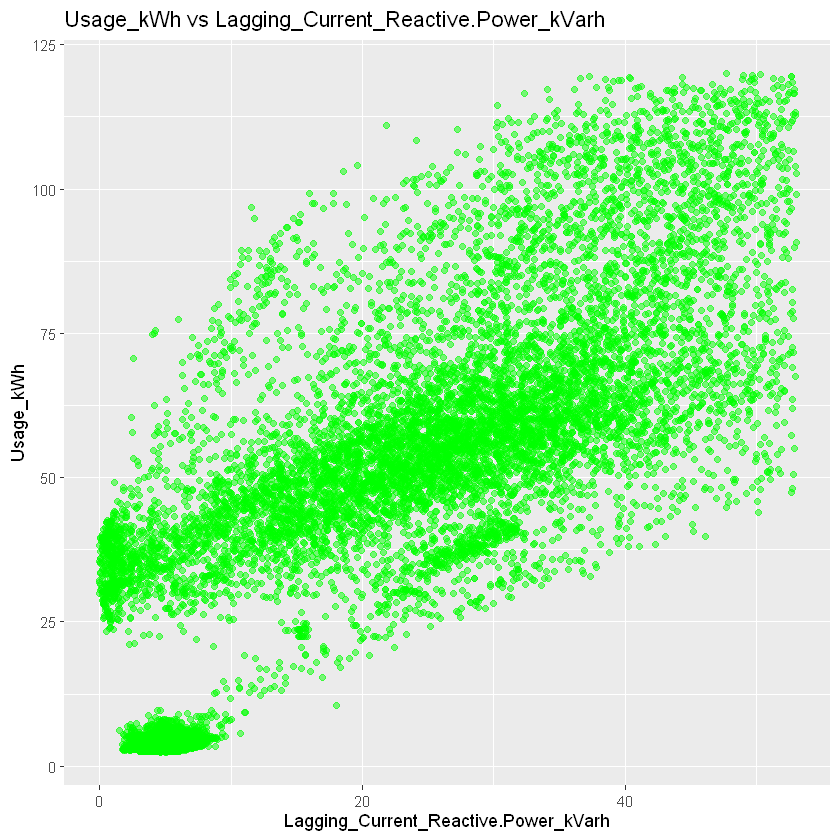

In [37]:
ggplot(data, aes(x=Lagging_Current_Reactive.Power_kVarh, y=Usage_kWh)) + geom_point(color="green", alpha=0.5) + labs(title="Usage_kWh vs Lagging_Current_Reactive.Power_kVarh", x="Lagging_Current_Reactive.Power_kVarh", y="Usage_kWh")

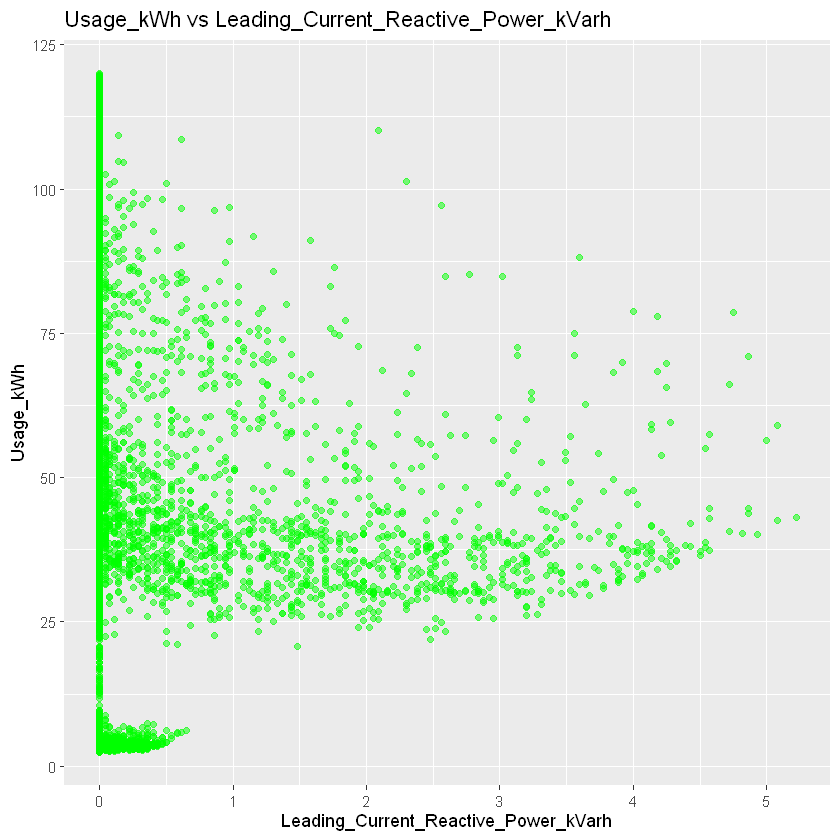

In [38]:
ggplot(data, aes(x=Leading_Current_Reactive_Power_kVarh, y=Usage_kWh)) + geom_point(color="green", alpha=0.5) + labs(title="Usage_kWh vs Leading_Current_Reactive_Power_kVarh", x="Leading_Current_Reactive_Power_kVarh", y="Usage_kWh")


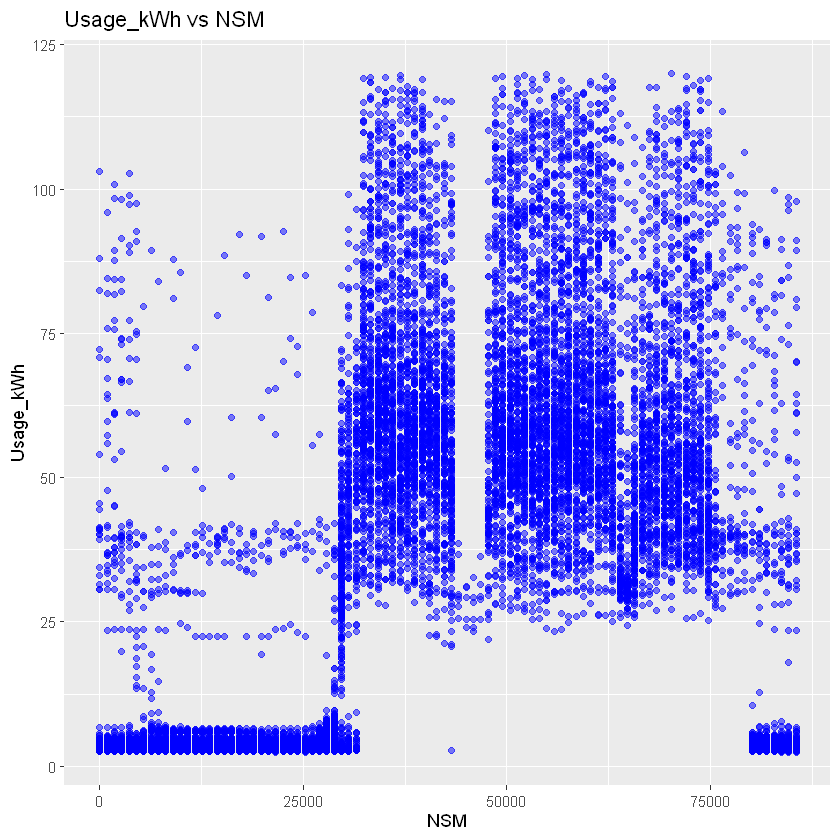

In [39]:
ggplot(data, aes(x=NSM, y=Usage_kWh)) + geom_point(color="blue", alpha=0.5) + labs(title="Usage_kWh vs NSM", x="NSM", y="Usage_kWh")

In [41]:
# Min-Max normalization function
min_max_norm <- function(x) {
  return((x - mean(x)) / sd(x))
}

reverse_standard_scale <- function(normalized_data, original_mean, original_sd) {
  return (normalized_data * original_sd + original_mean)
}

original_mean <- mean(data$Usage_kWh)
original_sd <- sd(data$Usage_kWh)

# Apply Min-Max normalization to numeric columns
data_normalized <- data %>%
  mutate(across(where(is.numeric), min_max_norm))

# Display the normalized data
head(data_normalized)

date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Day,Week_Status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
5/30/2018 2:45,-0.8445893,-0.7029075,-0.2262443,-0.8307350,-1.2777851,0.1970351,-1.0778847,-0.818936,Wed,0.5302004
2/23/2018 1:45,-0.7355525,-0.5333638,-0.2262443,-0.8307350,-0.4504968,0.1970351,-1.2201003,-0.818936,Fri,0.5302004
12/13/2018 13:30,0.8281339,0.5176668,-0.2262443,1.0904928,1.0489978,0.1970351,0.4509332,0.390365,Thu,0.5302004
4/15/2018 2:45,-0.8390135,-0.7809961,-0.2262443,-0.8307350,-0.6127535,0.1970351,-1.0778847,-0.818936,Sun,-1.8859867
7/23/2018 16:30,0.7844572,1.0649905,-0.2262443,1.0904928,0.7625651,0.1970351,0.8775800,1.599666,Mon,0.5302004
3/27/2018 16:30,0.2191387,-0.7788856,0.4256267,0.4500836,1.3994502,0.1970351,0.8775800,1.599666,Tue,0.5302004


In [42]:
test_normalize <- test %>%
  mutate(across(where(is.numeric), min_max_norm))
head(test_normalize)

date,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Day,Week_Status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
4/29/2018 7:15,-0.5708282,-0.5170607,-0.720693,-1.0849197,0.5115835,-0.6825697377,-0.8828745,Sun,-1.5923130
10/4/2018 12:00,2.1170421,-0.5170607,1.115450,-0.1172387,0.5115835,0.0001897238,1.6245965,Thu,0.6279276
1/26/2018 11:30,2.8242804,-0.5170607,2.951592,0.4736508,0.5115835,-0.0716796932,1.6245965,Fri,0.6279276
6/2/2018 14:30,-0.8031283,1.7394741,-0.720693,1.0242645,-2.1758828,0.3595368088,-0.8828745,Sat,-1.5923130
12/7/2018 15:00,0.4733060,-0.5170607,1.115450,0.7163660,0.5115835,0.4314062258,0.3708610,Fri,0.6279276
3/26/2018 6:00,-0.5908960,-0.5170607,-0.720693,-0.7558234,0.5115835,-0.8622432802,-0.8828745,Mon,0.6279276


In [46]:
library(Metrics)
library(caret)


Warning message:
"package 'caret' was built under R version 4.3.3"

Attaching package: 'caret'


The following objects are masked from 'package:Metrics':

    precision, recall


The following object is masked from 'package:purrr':

    lift




In [47]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra
trainIndex = createDataPartition(data_normalized$Usage_kWh, p= 0.8, list=FALSE, times=1)
trainData = data_normalized[trainIndex,]
testData = data_normalized[-trainIndex,]

# In ra thông tin tập huấn luyện
head(trainData)

date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Day,Week_Status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
5/30/2018 2:45,-0.8445893,-0.7029075,-0.2262443,-0.8307350,-1.2777851,0.1970351,-1.0778847,-0.818936,Wed,0.5302004
2/23/2018 1:45,-0.7355525,-0.5333638,-0.2262443,-0.8307350,-0.4504968,0.1970351,-1.2201003,-0.818936,Fri,0.5302004
12/13/2018 13:30,0.8281339,0.5176668,-0.2262443,1.0904928,1.0489978,0.1970351,0.4509332,0.390365,Thu,0.5302004
4/15/2018 2:45,-0.8390135,-0.7809961,-0.2262443,-0.8307350,-0.6127535,0.1970351,-1.0778847,-0.818936,Sun,-1.8859867
7/23/2018 16:30,0.7844572,1.0649905,-0.2262443,1.0904928,0.7625651,0.1970351,0.8775800,1.599666,Mon,0.5302004
3/27/2018 16:30,0.2191387,-0.7788856,0.4256267,0.4500836,1.3994502,0.1970351,0.8775800,1.599666,Tue,0.5302004


In [48]:
model <- lm(Usage_kWh ~ Lagging_Current_Power_Factor + Leading_Current_Power_Factor + 
            Lagging_Current_Reactive.Power_kVarh + Leading_Current_Reactive_Power_kVarh + 
            `CO2(tCO2)`, data = trainData)
summary(model)



Call:
lm(formula = Usage_kWh ~ Lagging_Current_Power_Factor + Leading_Current_Power_Factor + 
    Lagging_Current_Reactive.Power_kVarh + Leading_Current_Reactive_Power_kVarh + 
    `CO2(tCO2)`, data = trainData)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.43896 -0.03746  0.00555  0.03336  3.02991 

Coefficients:
                                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          6.165e-05  1.123e-03   0.055  0.95624    
Lagging_Current_Power_Factor         6.873e-02  1.995e-03  34.454  < 2e-16 ***
Leading_Current_Power_Factor         1.114e-02  1.763e-03   6.319  2.7e-10 ***
Lagging_Current_Reactive.Power_kVarh 1.099e-01  2.582e-03  42.575  < 2e-16 ***
Leading_Current_Reactive_Power_kVarh 5.689e-03  1.817e-03   3.132  0.00174 ** 
`CO2(tCO2)`                          8.381e-01  3.316e-03 252.731  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1435 on 16303 degree

In [49]:
predictions = predict(model, newdata=testData)

# In ra thông tin dự đoán
print("Thông tin dự đoán:")
head(data.frame(Id = 1:length(predictions), Usage_Kwh = predictions))


[1] "Thông tin dự đoán:"


,Id,Usage_Kwh
,<int>,<dbl>
1,1,1.1431596
2,2,1.0718772
3,3,0.4394965
4,4,-0.7791904
5,5,0.4707577
6,6,-0.7831479


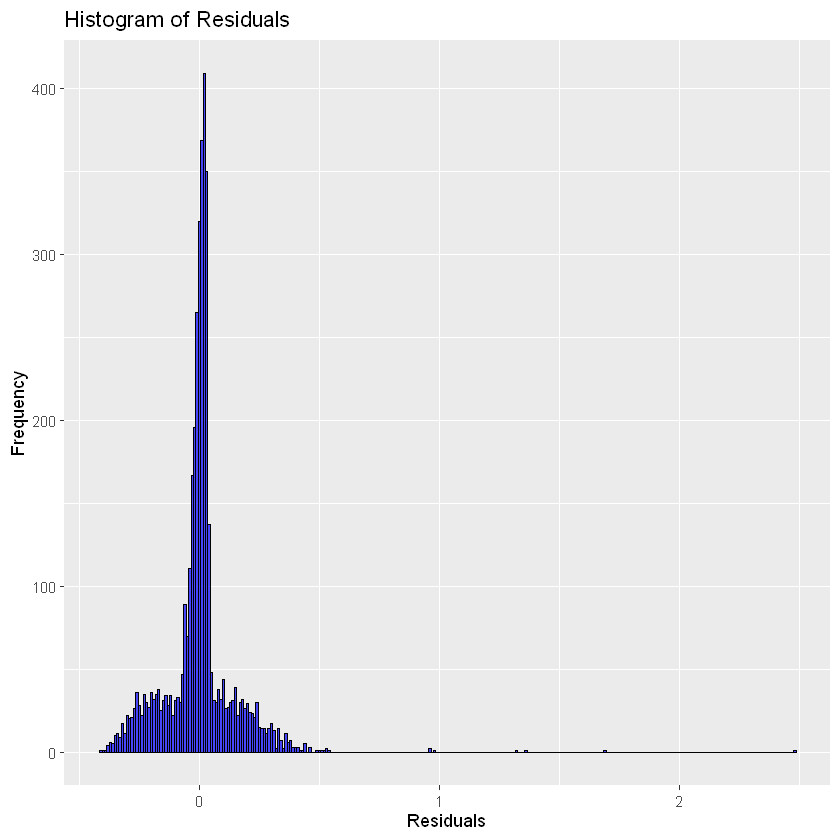

In [50]:
residuals <- testData$Usage_kWh - predictions

ggplot(data.frame(residuals=residuals), aes(x=residuals)) +
  geom_histogram(binwidth=0.01, fill='blue', color='black', alpha=0.7) +
  labs(title='Histogram of Residuals', x='Residuals', y='Frequency')

In [51]:
# Tính toán các chỉ số đánh giá
mse <- mse(testData$Usage_kWh, predictions)
rmse <- rmse(testData$Usage_kWh, predictions)
r2 <- R2(testData$Usage_kWh, predictions)

print(paste('MSE: ', mse))
print(paste('RMSE: ', rmse))
print(paste('R-squared: ', r2))

[1] "MSE:  0.0207766929762406"
[1] "RMSE:  0.144141225803864"
[1] "R-squared:  0.979314525608241"


In [52]:
cat("Accuracy:", (1-mse)*100)
cat("%")

Accuracy: 97.92233%

In [53]:
prediction <-  predict.lm(model, newdata = test_normalize)
# In ra thông tin dự đoán
print("Thông tin dự đoán:")
head(prediction)

[1] "Thông tin dự đoán:"


1          2          3          4          5          6 
-0.7384843  1.1623412  2.8195019 -0.6361813  1.0389030 -0.7180734

In [54]:
new_df <- data.frame(Id = 1:7008 ,Usage_kWh = prediction)

# Print the new dataframe
new_df$Usage_kWh <- reverse_standard_scale(new_df$Usage_kWh, original_mean, original_sd)
print(head(new_df))

  Id  Usage_kWh
1  1   6.345355
2  2  67.709112
3  3 121.206711
4  4   9.647970
5  5  63.724192
6  6   7.004272


In [56]:
write.csv(new_df, "prediction.csv", row.names = FALSE)
